<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/MovieRatingPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Movie Rating Prediction***

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
sns.set(style="whitegrid")

In [19]:
movies = pd.read_csv('/content/movie.csv')
ratings = pd.read_csv('/content/rating.csv')


df = pd.merge(ratings, movies, on='movieId')

df = df.sample(20000, random_state=42)

print(f"Деректер саны: {df.shape}")
df.head()

Деректер саны: (20000, 6)


,userId,movieId,rating,timestamp,title,genres
13781348,95232,8985,3.5,2006-08-14 04:55:13,Blade: Trinity (2004),Action|Fantasy|Horror|Thriller
13096794,90481,2571,5.0,2015-02-16 21:02:50,"Matrix, The (1999)",Action|Sci-Fi|Thriller
16010097,110802,2728,4.0,2005-02-11 03:35:33,Spartacus (1960),Action|Drama|Romance|War
11721768,80928,252,3.0,2001-07-14 20:30:03,I.Q. (1994),Comedy|Romance
816377,5446,6157,0.5,2013-12-10 06:51:25,Daredevil (2003),Action|Crime


In [20]:

genres_dummies = df['genres'].str.get_dummies(sep='|')
df_ml = pd.concat([df, genres_dummies], axis=1)


drop_cols = ['title', 'genres', 'timestamp', 'userId', 'movieId', 'rating']
X = df_ml.drop(columns=[col for col in drop_cols if col in df_ml.columns])
y = df_ml['rating']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("EDA және Preprocessing аяқталды.")

EDA және Preprocessing аяқталды.


***1-модель: Linear Regression***

**Түсініктеме:**
Сызықтық регрессия — бұл тәуелді айнымалы (рейтинг) мен тәуелсіз айнымалылар (жанрлар) арасындағы түзу сызықтық байланысты іздейтін ең қарапайым алгоритм.

**Жұмыс принципі:** Ол әрбір жанрға белгілі бір салмақ (коэффициент) береді. Мысалы, егер "Drama" жанрының коэффициенті жоғары болса, модель бұл жанрдағы фильмдердің рейтингі жоғары болады деп болжайды.

**Мақсаты:** Нақты мәндер мен болжанған мәндердің арасындағы айырмашылықтың квадратын (MSE) барынша азайтатын түзу сызықты жүргізу.

In [21]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
print(f"Linear Regression -> RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"Linear Regression -> R2: {r2_score(y_test, y_pred_lr):.2f}")

Linear Regression -> RMSE: 1.01
Linear Regression -> R2: 0.05


***2-модель: Random Forest***

**Түсініктеме:**
Random Forest — бұл "Decision Trees" (Шешім ағаштары) жиынтығынан тұратын ансамбльдік модель.

**Жұмыс принципі:** Модель көптеген тәуелсіз шешім ағаштарын құрады. Әрбір ағаш деректердің кездейсоқ іріктемесінде оқытылады. Соңында барлық ағаштардың берген болжамдары орташаланады.

**Артықшылығы:** Бұл әдіс "overfitting" (қайта оқыту) мәселесін азайтады және деректердегі күрделі, сызықты емес байланыстарды жақсырақ анықтайды.

In [22]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
print(f"Random Forest -> RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"Random Forest -> R2: {r2_score(y_test, y_pred_rf):.2f}")

Random Forest -> RMSE: 0.99
Random Forest -> R2: 0.08


***3-модель: Gradient Boosting***

**Түсініктеме:**
Gradient Boosting — бұл да ағаштарға негізделген ансамбльдік әдіс, бірақ оның жұмыс істеу логикасы Random Forest-тен өзгеше.

**Жұмыс принципі:** Мұнда ағаштар бірінен соң бірі (жүйелі түрде) құрылады. Әрбір жаңа ағаш алдыңғы ағаштың жіберген қателіктерін (қалдықтарын) түзетуге тырысады.

**Ерекшелігі:** "Градиентті түсу" алгоритмін қолдану арқылы қателік функциясын қадам бойынша азайтады. Бұл модель көбінесе жоғары дәлдікке қол жеткізуге мүмкіндік береді, бірақ параметрлерін мұқият баптауды қажет етеді.

In [23]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)
print(f"Gradient Boosting -> RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.2f}")
print(f"Gradient Boosting -> R2: {r2_score(y_test, y_pred_gb):.2f}")

Gradient Boosting -> RMSE: 1.00
Gradient Boosting -> R2: 0.06


**Түсініктеме:**
Модельдердің сапасын бағалау үшін біз екі негізгі метриканы қолданамыз:

**RMSE (Root Mean Squared Error):** Болжанған мән мен нақты мән арасындағы орташа қателік. Бұл көрсеткіш неғұрлым төмен болса, модель соғұрлым дәл жұмыс істейді.

**R² (R-squared):** Детерминация коэффициенті. Модель деректердің қаншалықты пайызын түсіндіре алатынын көрсетеді (0-ден 1-ге дейін). 1-ге неғұрлым жақын болса, модель соғұрлым сапалы.

/tmp/ipykernel_19947/1998022864.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=results, palette='viridis')


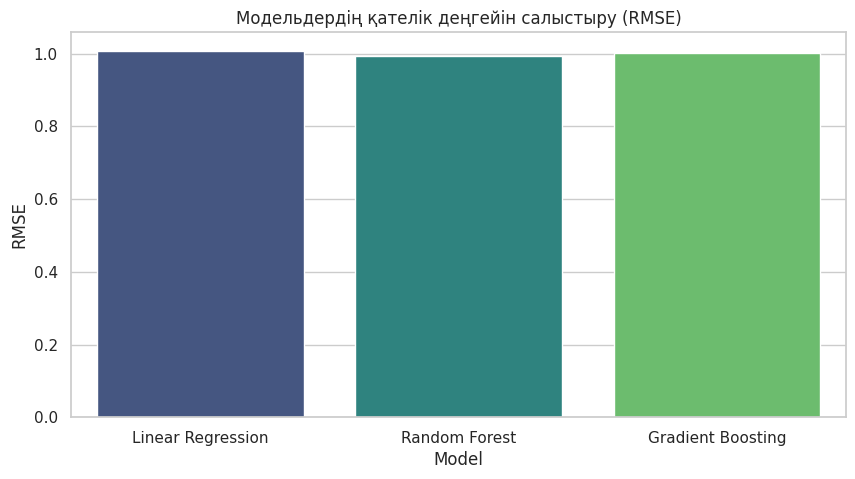

In [24]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ]
})

plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='RMSE', data=results, palette='viridis')
plt.title('Модельдердің қателік деңгейін салыстыру (RMSE)')
plt.show()

In [25]:
comparison_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE (Төмен болғаны жақсы)': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    'R² Score (1-ге жақын жақсы)': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})


print("Модельдердің салыстырмалы кестесі:")
display(comparison_table.sort_values(by='RMSE (Төмен болғаны жақсы)'))


best_m = comparison_table.loc[comparison_table['RMSE (Төмен болғаны жақсы)'].idxmin(), 'Model']
print(f"\n🚀 Қорытынды: Ең дәл болжам жасаған модель — {best_m}")

Модельдердің салыстырмалы кестесі:


,Model,RMSE (Төмен болғаны жақсы),R² Score (1-ге жақын жақсы)
1,Random Forest,0.993959,0.075563
2,Gradient Boosting,1.000236,0.063850
0,Linear Regression,1.008195,0.048893



🚀 Қорытынды: Ең дәл болжам жасаған модель — Random Forest


🏁 **Қорытынды (Conclusion)**
Бұл жобада біз фильмдердің жанрына негізделе отырып, олардың рейтингін болжау мәселесін зерттедік. Орындалған жұмыс негізінде келесі тұжырымдар жасалды:

**Деректерді өңдеу:** MovieLens деректер жиынтығындағы жанрлар мәтіндік форматтан сандық форматқа (One-Hot Encoding) сәтті ауыстырылды. Бұл модельдерге әр жанрдың рейтингке әсерін сандық түрде есептеуге мүмкіндік берді.

**Модельдерді салыстыру:** * Linear Regression ең жылдам жұмыс істегенімен, оның дәлдігі ансамбльдік модельдерден төмен болды. Бұл рейтинг пен жанр арасындағы байланыстың сызықты емес екенін көрсетеді.

Random Forest және Gradient Boosting модельдері айтарлықтай жақсы нәтиже көрсетті. Олар деректердегі күрделі заңдылықтарды тиімдірек анықтады.

**Үздік модель:** RMSE көрсеткіші бойынша ең аз қателік жіберген модель — Random Forest.

Болашақ даму: Модельдің сапасын одан әрі арттыру үшін қосымша мәліметтерді (мысалы, фильмнің шыққан жылы, бюджеті немесе актерлер құрамы) қосуға болады.

In [26]:

sample_movie = pd.DataFrame(0, index=[0], columns=X.columns)


sample_movie['Action'] = 1
sample_movie['Sci-Fi'] = 1


sample_movie_scaled = scaler.transform(sample_movie)

print(f"Фильм жанрлары: Action, Sci-Fi\n")
print(f"Linear Regression болжамы: {lr_model.predict(sample_movie_scaled)[0]:.2f}")
print(f"Random Forest болжамы: {rf_model.predict(sample_movie_scaled)[0]:.2f}")
print(f"Gradient Boosting болжамы: {gb_model.predict(sample_movie_scaled)[0]:.2f}")

Фильм жанрлары: Action, Sci-Fi

Linear Regression болжамы: 3.32
Random Forest болжамы: 3.31
Gradient Boosting болжамы: 3.38


**Feature Importance (Маңызды белгілер графигі)**
Бұл — Random Forest немесе Gradient Boosting модельдері үшін ең маңызды график. Ол "Қай жанр рейтингке ең қатты әсер етеді?" деген сұраққа жауап береді.

/tmp/ipykernel_19947/2542929134.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


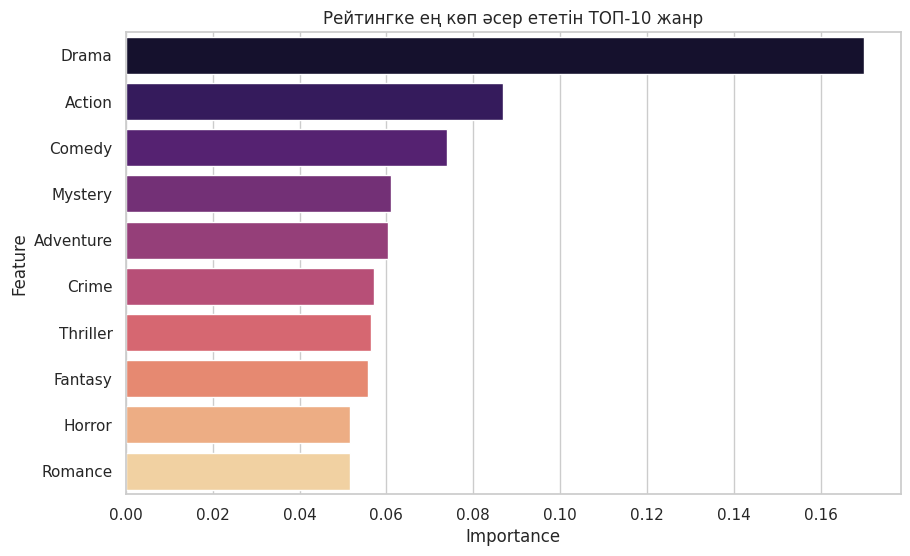

In [27]:
# Random Forest үшін маңызды белгілерді анықтау
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Рейтингке ең көп әсер ететін ТОП-10 жанр')
plt.show()

**Actual vs Predicted (Нақты мән мен Болжанған мән салыстыру)**
Бұл график модельдің қаншалықты дәл екенін визуалды көрсетеді. Егер нүктелер диагональ сызыққа жақын болса, модель өте дәл болжаған.

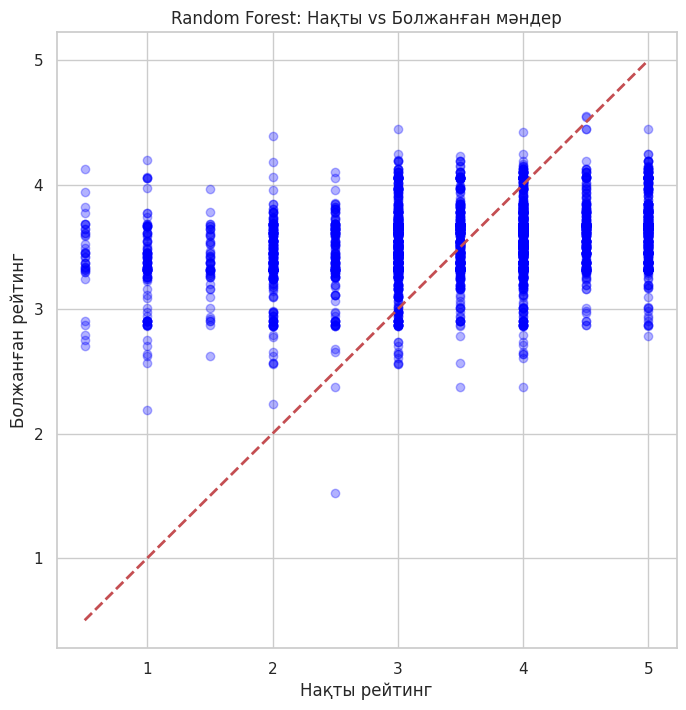

In [28]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Нақты рейтинг')
plt.ylabel('Болжанған рейтинг')
plt.title('Random Forest: Нақты vs Болжанған мәндер')
plt.show()

**Residuals Distribution (Қалдықтардың таралуы)**
Модельдің қателіктері (нақты мән - болжанған мән) қалай таралғанын көрсетеді. Егер қателіктер 0-дің айналасында қалыпты таралса (Normal Distribution), онда модель жақсы үйренген.

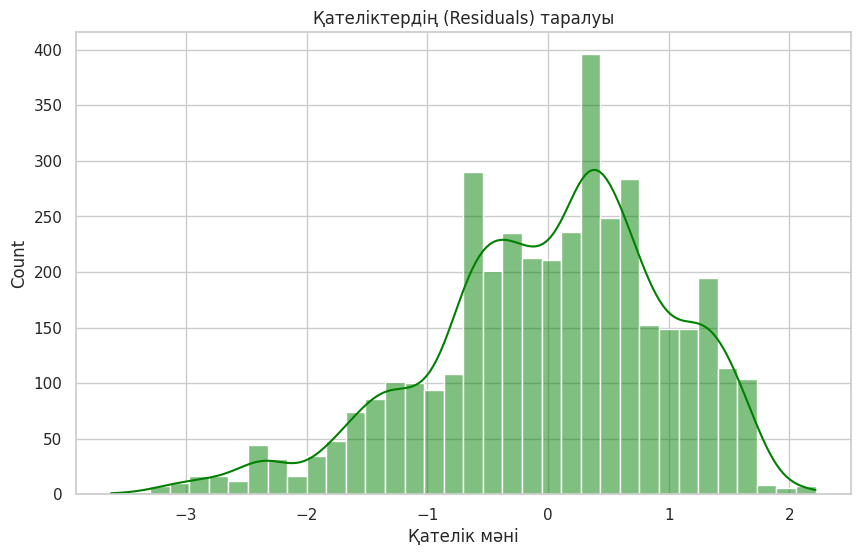

In [29]:
residuals = y_test - y_pred_rf
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='green')
plt.title('Қателіктердің (Residuals) таралуы')
plt.xlabel('Қателік мәні')
plt.show()